In [59]:
#
# Importing the necessary libraries: 
# NumPy, SciPy (spatial algorithms), timing functions, a handler for csv files 
#
import numpy as np
import scipy.spatial as sp
import time
import csv

In [60]:
#
# Centering a point cloud A
#
def barycentered(A):
    #
    bar = np.sum(A, axis=1)/A.shape[1]
    #
    return np.array([vec - bar for vec in A.T]).T

In [61]:
#
# Best orthogonal fit between two (centred) labelled point clouds
# A and B are assumed to have the same number of points
#
def best_fit(A, B):
    #
    na = A.shape[1]
    nb = B.shape[1]
    #
    assert na==nb
    #
    H = A @ B.T
    W, S, V = np.linalg.svd(H)
    #
    return V.T @ W.T

In [62]:
#
# Detecting nearest neighbours between two unlabelled point coluds A and B
#
# Assumption: cardinality of A <= cardinality of B 
#
# Input: point clouds A, B
#
# Output: for each point of A a matching point of B, as a 0/1-matrix
#
def nearest_neighbours(A, B):
    #
    na = A.shape[1]
    nb = B.shape[1]
    #
    assert na <= nb
    #
    tree = sp.KDTree(A.T, leafsize=10, compact_nodes=True, copy_data=True, balanced_tree=True)
    #
    matching = []
    I = matrix.identity(na)
    #
    for i in range(nb):
        _, ind = tree.query(B.T[i], k=1, p=2, workers=-1)
        matching += [I[ind]]
    #    
    return np.array(matching)

In [63]:
#
# ICP algorithm for two unlabelled point clouds A and B
#
# Assumption: cardinality of A <= cardinality of B
#
# Input:
# A, B = unlabelled point clouds
# init = initial orthogonal transformation
# max_iter = maximum number of iterations
# tol = tolerance for halting the computation
#
# Output:
# U = orthogonal transformation bringing A to B as close as possible
# nn = nearest neighbor matching between U*A and B
# dist = distance between U*A*nn and B (in the max singular value norm)
#
def icp(A, B, init=None, max_iter=100, tol=1e-16):
    #
    src = copy(A)
    dst = copy(B)
    #
    na = src.shape[1]
    nb = src.shape[1]
    #
    assert na <= nb
    #
    if (init is not None):
        src = init @ src
    #    
    prev_err = 0
    #
    for i in range(max_iter):
        #   
        nn = nearest_neighbours(src, dst)
        U = best_fit(src, dst @ nn)
        #    
        src = U @ src
        #
        diff = src - dst @ nn
        err  = np.linalg.norm(diff, 2)
        #
        if abs(prev_err - err) < tol:
            break
        #    
        prev_err = err
    #
    U = best_fit(A, src)
    nn = nearest_neighbours(U @ A, dst)
    #
    diff = U @ A - B @ nn
    dist = np.linalg.norm(diff, 2)
    #
    return U, nn, dist

In [64]:
#
# Testing the Main Algorithm on occluded point clouds 
#
# We use the unoccluded version of the Caerbannog Point Clouds
# and produce the occlusing points on our own: this allows us
# to easily control the level of occlusion
#
# Occluding points are uniformly represented within the bounding
# box of the initial unoccluded image
#

In [65]:
#
# Raghupathi, Sunand; Brunhart-Lupo, Nicholas; Gruchalla, Kenny (2020)
# "Caerbannog Point Clouds". National Renewable Energy Laboratory. 10.7799/1729892
# Source: https://data.nrel.gov/submissions/153
#

In [66]:
#
# Testing the Algorithm on point clouds with different levels of occlusion.
#
# Input: an unoccluded point cloud P, occlusion level 
#
# Producing another point cloud Q0 = O * P * S, with O a random orthogonal transformation
# and S a random permutation. Then adding some extra occlusion points X to Q0 in order to 
# obtain a new *occluded* point cloud Q. This is control by level variable: level = % of 
# added occlusion points, a positive real number.  
#
# Test: determine the distance dist_spec from the recovered image of P denoted by 
# R = o * P * S to the specimen Q0, and compare it to the distance between d_icp between 
# o * P * s and Q returned by the ICP algorithm.
#
# Here it is important to note that S is a permutation, while s is a matching of nearest 
# neighbours in o * P and Q. The latter does not have to be a permutation matrix. 
#
def test_point_cloud(P, level=0.1, tol=0.05, verbose=False):
    #
    dim = P.shape[0]
    num = P.shape[1]
    occ = int(num * level)
    normP = np.linalg.norm(P, 2)
    if verbose:
        print("Number of genuine points:   {}".format(num))
        print("Number of occlusion points: {}".format(occ))
    #
    Sym = SymmetricGroup(num + occ) 
    #
    seed = np.array([np.random.normal(0.0, 1.0) for _ in range(dim^2)]).reshape(dim,dim)
    O = np.linalg.qr(seed, mode='complete')[0]
    S = np.array(Sym.random_element().matrix())
    #
    P = barycentered(P)
    #
    Q0 = O @ P
    X  = [np.random.uniform(np.min(P[i,:]), np.max(P[i,:]), occ) for i in range(dim)]
    X  = np.array(X)
    X  = O @ X
    dist_occ = np.linalg.norm(X, 2) / normP
    if verbose:
        print("Occlusion introduced (normalised): {}".format(dist_occ))
    #
    Q = np.c_[Q0, X]
    Q = Q @ S
    Q = barycentered(Q)
    #
    Ep = P @ P.T
    Eigp, Up = np.linalg.eigh(Ep)
    #
    Eq = Q @ Q.T
    Eigq, Uq = np.linalg.eigh(Eq)
    #
    U0 = Uq @ Up.T
    #
    isoms_discrete = MatrixGroup([matrix.diagonal(d) for d in Permutations([-1]+[1]*(dim-1))])
    isoms_discrete = [np.array(matrix(m)) for m in isoms_discrete]
    #
    sols = []
    for isom in isoms_discrete:
        U = U0 @ Up @ isom @ Up.T
        nn = nearest_neighbours(U @ P, Q)
        diff_init = U @ P - Q @ nn
        d_init = np.linalg.norm(diff_init, 2) / normP
        sols += [(U, nn, d_init)]
    sols = sorted(sols, key=lambda x: x[2])
    o_init, s_init, dist_init = sols[0]
    o, s, d = icp(P, Q, o_init)
    dist_icp = d / normP
    delta_icp = dist_init - dist_icp
    diff = o_init - o
    delta_ortho_icp = np.linalg.norm(diff, 2)
    R = o @ P
    diff = Q0 - R
    dist_spec = np.linalg.norm(diff, 2) / normP
    diff = o - O
    dist_ortho = np.linalg.norm(diff, 2)
    if verbose:
        print("Orthogonal transformation found:")
        print(o)
        print("Distance to the initial one?")
        print(dist_ortho)
        print("Normalised distance to occluded image:")
        print(dist_icp)
        print("Actual distance to specimen (normalised):")
        print(dist_spec)
        print("ICP improvement (normalised):")
        print(delta_icp)
        print("ICP change to orthogonal transformation:")
        print(delta_ortho_icp)
    #
    flag = ( dist_spec < tol )
    #
    return flag, dist_occ, dist_icp, delta_icp, delta_ortho_icp, dist_spec, dist_ortho

In [67]:
#
# Running a given number of tests num_tests on a given point cloud 
# generated by calling test_random(dim, num, min_coord, max_coord)
#
# Some statistics is collected and printed as output
#
def run_tests_point_cloud(P, num_tests, level=0.1, tol=0.05, verbose=False):
    #
    num_success = 0
    num_fail  = 0
    rec_dist_noise = []
    rec_dist_icp = []
    rec_delta_icp = []
    rec_delta_ortho_icp = []
    rec_dist_spec = []
    rec_dist_ortho = []
    #
    start = time.process_time()
    #
    for i in range(num_tests):
        test_flag = False
        print("#"*16+" Test #{} ".format(i+1)+"#"*16)
        #
        test_flag, test_dist_noise, test_dist_icp, test_delta_icp,\
        test_delta_ortho_icp, test_dist_spec,\
        test_dist_ortho = test_point_cloud(P, level, tol, verbose)
        #
        rec_dist_noise += [test_dist_noise]
        rec_dist_icp += [test_dist_icp]
        rec_delta_icp += [test_delta_icp]
        rec_delta_ortho_icp += [test_delta_ortho_icp]
        rec_dist_spec += [test_dist_spec]
        rec_dist_ortho += [test_dist_ortho]
        if test_flag:
            print("SUCCESS")
            num_success += 1
        else:
            print("FAIL")
            num_fail += 1
        print("#"*42)
    #
    end = time.process_time()
    #
    assert (num_success + num_fail == num_tests)
    #
    avg_dist_noise = np.mean(rec_dist_noise)
    avg_dist_icp = np.mean(rec_dist_icp)
    avg_delta_icp = np.mean(rec_delta_icp)
    avg_delta_ortho_icp = np.mean(rec_delta_ortho_icp)
    avg_dist_spec = np.mean(rec_dist_spec)
    avg_dist_ortho = np.mean(rec_dist_ortho)
    #
    print("Time elapsed:", time.strftime('%H:%M:%S', time.gmtime(end-start)))
    print("Success rate:", float(num_success/num_tests))
    print("======= Mean values =======")
    print("Occlusion added (normalised): {}".format(avg_dist_noise))
    print("Distance to occluded image (normalised): {}".format(avg_dist_icp))
    print("Distance to specimen (normalised): {}".format(avg_dist_spec))
    print("Distance to initial orthogonal transformation: {}".format(avg_dist_ortho))
    print("ICP improvement (normalised): {}".format(avg_delta_icp))
    print("ICP change to orthogonal transformation: {}".format(avg_delta_ortho_icp))

In [68]:
#
# The following unoclluded point clouds are used: teapot, bunny, cow. 
# The occlusion level is 0.2, in which case most tests pass. 
#
filenames = ["Teapot.csv", "Bunny.csv", "Cow.csv"]
#
for name in filenames:
    #
    P = []
    #
    f = open(name)
    reader = csv.reader(f)
    #
    for line in reader:
        P += [[RDF(line[j]) for j in range(3)]]
    #    
    f.close()
    #    
    P = np.array(P).T
    #
    print("File read: {}".format(name))
    #
    run_tests_point_cloud(P, num_tests=100, level=0.2, tol=0.05, verbose=False)
    #
    print("#"*42)

File read: Teapot.csv
################ Test #1 ################
SUCCESS
##########################################
################ Test #2 ################
SUCCESS
##########################################
################ Test #3 ################
SUCCESS
##########################################
################ Test #4 ################
SUCCESS
##########################################
################ Test #5 ################
SUCCESS
##########################################
################ Test #6 ################
SUCCESS
##########################################
################ Test #7 ################
SUCCESS
##########################################
################ Test #8 ################
SUCCESS
##########################################
################ Test #9 ################
SUCCESS
##########################################
################ Test #10 ################
SUCCESS
##########################################
################ Test #11 ################
SUCC

SUCCESS
##########################################
################ Test #89 ################
SUCCESS
##########################################
################ Test #90 ################
SUCCESS
##########################################
################ Test #91 ################
SUCCESS
##########################################
################ Test #92 ################
SUCCESS
##########################################
################ Test #93 ################
SUCCESS
##########################################
################ Test #94 ################
SUCCESS
##########################################
################ Test #95 ################
SUCCESS
##########################################
################ Test #96 ################
SUCCESS
##########################################
################ Test #97 ################
SUCCESS
##########################################
################ Test #98 ################
SUCCESS
##########################################
#########

SUCCESS
##########################################
################ Test #72 ################
SUCCESS
##########################################
################ Test #73 ################
SUCCESS
##########################################
################ Test #74 ################
SUCCESS
##########################################
################ Test #75 ################
SUCCESS
##########################################
################ Test #76 ################
SUCCESS
##########################################
################ Test #77 ################
SUCCESS
##########################################
################ Test #78 ################
SUCCESS
##########################################
################ Test #79 ################
SUCCESS
##########################################
################ Test #80 ################
SUCCESS
##########################################
################ Test #81 ################
SUCCESS
##########################################
#########

SUCCESS
##########################################
################ Test #55 ################
SUCCESS
##########################################
################ Test #56 ################
SUCCESS
##########################################
################ Test #57 ################
SUCCESS
##########################################
################ Test #58 ################
SUCCESS
##########################################
################ Test #59 ################
SUCCESS
##########################################
################ Test #60 ################
SUCCESS
##########################################
################ Test #61 ################
SUCCESS
##########################################
################ Test #62 ################
SUCCESS
##########################################
################ Test #63 ################
SUCCESS
##########################################
################ Test #64 ################
SUCCESS
##########################################
#########

In [69]:
#
# The following unoclluded point clouds are used: teapot, bunny, cow. 
# The occlusion level is 1.2, in which case most tests fail. 
#
filenames = ["Teapot.csv", "Bunny.csv", "Cow.csv"]
#
for name in filenames:
    #
    P = []
    #
    f = open(name)
    reader = csv.reader(f)
    #
    for line in reader:
        P += [[RDF(line[j]) for j in range(3)]]
    #    
    f.close()
    #    
    P = np.array(P).T
    #
    print("File read: {}".format(name))
    #
    run_tests_point_cloud(P, num_tests=100, level=1.2, tol=0.05, verbose=False)
    #
    print("#"*42)

File read: Teapot.csv
################ Test #1 ################
FAIL
##########################################
################ Test #2 ################
FAIL
##########################################
################ Test #3 ################
SUCCESS
##########################################
################ Test #4 ################
SUCCESS
##########################################
################ Test #5 ################
SUCCESS
##########################################
################ Test #6 ################
FAIL
##########################################
################ Test #7 ################
SUCCESS
##########################################
################ Test #8 ################
SUCCESS
##########################################
################ Test #9 ################
SUCCESS
##########################################
################ Test #10 ################
FAIL
##########################################
################ Test #11 ################
SUCCESS
########

SUCCESS
##########################################
################ Test #91 ################
SUCCESS
##########################################
################ Test #92 ################
FAIL
##########################################
################ Test #93 ################
FAIL
##########################################
################ Test #94 ################
FAIL
##########################################
################ Test #95 ################
FAIL
##########################################
################ Test #96 ################
FAIL
##########################################
################ Test #97 ################
SUCCESS
##########################################
################ Test #98 ################
FAIL
##########################################
################ Test #99 ################
SUCCESS
##########################################
################ Test #100 ################
FAIL
##########################################
Time elapsed: 00:22:36
Succes

FAIL
##########################################
################ Test #76 ################
FAIL
##########################################
################ Test #77 ################
FAIL
##########################################
################ Test #78 ################
FAIL
##########################################
################ Test #79 ################
FAIL
##########################################
################ Test #80 ################
FAIL
##########################################
################ Test #81 ################
FAIL
##########################################
################ Test #82 ################
FAIL
##########################################
################ Test #83 ################
FAIL
##########################################
################ Test #84 ################
FAIL
##########################################
################ Test #85 ################
FAIL
##########################################
################ Test #86 ################

FAIL
##########################################
################ Test #61 ################
SUCCESS
##########################################
################ Test #62 ################
SUCCESS
##########################################
################ Test #63 ################
FAIL
##########################################
################ Test #64 ################
FAIL
##########################################
################ Test #65 ################
FAIL
##########################################
################ Test #66 ################
FAIL
##########################################
################ Test #67 ################
FAIL
##########################################
################ Test #68 ################
FAIL
##########################################
################ Test #69 ################
FAIL
##########################################
################ Test #70 ################
FAIL
##########################################
################ Test #71 ##########

In [70]:
#
# Running a given number of tests num_tests on a given point cloud
#
# Output is then used to plot graphs of test stats
#
def point_cloud_stats(P, num_tests, level=0.1, tol=0.05):
    #
    num_success = 0
    num_fail  = 0
    rec_dist_noise = []
    rec_dist_icp = []
    rec_delta_icp = []
    rec_delta_ortho_icp = []
    rec_dist_spec = []
    rec_dist_ortho = []
    #
    start = time.process_time()
    #
    for i in range(num_tests):
        test_flag = False
        #
        test_flag, test_dist_noise, test_dist_icp,\
        test_delta_icp, test_delta_ortho_icp, test_dist_spec,\
        test_dist_ortho = test_point_cloud(P, level, tol, verbose=False)
        #
        rec_dist_noise += [test_dist_noise]
        rec_dist_icp += [test_dist_icp]
        rec_delta_icp += [test_delta_icp]
        rec_delta_ortho_icp += [test_delta_ortho_icp]
        rec_dist_spec += [test_dist_spec]
        rec_dist_ortho += [test_dist_ortho]
        if test_flag:
            num_success += 1
        else:
            num_fail += 1
    #
    end = time.process_time()
    #
    assert (num_success + num_fail == num_tests)
    #
    success_rate = float(num_success/num_tests)
    avg_dist_noise = np.mean(rec_dist_noise)
    avg_dist_icp = np.mean(rec_dist_icp)
    avg_delta_icp = np.mean(rec_delta_icp)
    avg_delta_ortho_icp = np.mean(rec_delta_ortho_icp)
    avg_dist_spec = np.mean(rec_dist_spec)
    avg_dist_ortho = np.mean(rec_dist_ortho)
    #
    return success_rate, avg_dist_noise, avg_dist_icp, avg_delta_icp, avg_delta_ortho_icp,\
           avg_dist_spec, avg_dist_ortho

In [71]:
#
# Produces data for plotting test stats
#
def plot_point_cloud_stats(P, num_tests, level_array, tol=0.05):
    stats = []
    for level in level_array:
        test_stats = point_cloud_stats(P, num_tests, level, tol)
        test_stats = (level,) + test_stats
        stats += [test_stats]
    return stats 

In [76]:
#
# The following unoclluded point clouds are used: teapot, bunny, cow. 
#
# The level of occlusion added takes consecutive values in [0.2, 0.4, ..., 1.2] 
#
#
filenames = ["Teapot.csv", "Bunny.csv", "Cow.csv"]
data = []
#
for name in filenames:
    #
    P = []
    #
    f = open(name)
    reader = csv.reader(f)
    #
    for line in reader:
        P += [[RDF(line[j]) for j in range(3)]]
    #   
    f.close()
    #    
    P = np.array(P).T
    #
    print("File read: {}".format(name))
    #
    plt = plot_point_cloud_stats(P, num_tests=100, level_array=np.arange(0.2,1.4,0.2), tol=0.05)
    data += [(name, plt)]
    #
    print("Test stats produced ...")

File read: Teapot.csv
Test stats produced ...
File read: Bunny.csv
Test stats produced ...
File read: Cow.csv
Test stats produced ...


In [77]:
#
# Test stats prduced have the following structure:
#
# data[_][0] : cloud file name = Teapot.csv, Bunny.csv, or Cow.csv
#
# data[_][1] = stats : test stats where stats[i] stands for
#
# i=0: sigma2,
# i=1: success_rate, 
# i=2: avg_dist_noise, 
# i=3: avg_dist_icp, 
# i=4: avg_delta_icp, 
# i=5: avg_delta_ortho_icp,
# i=6: avg_dist_spec, 
# i=7: avg_dist_ortho, 
# i=8: avg_dist_per
#

Teapot.csv
Bunny.csv
Cow.csv


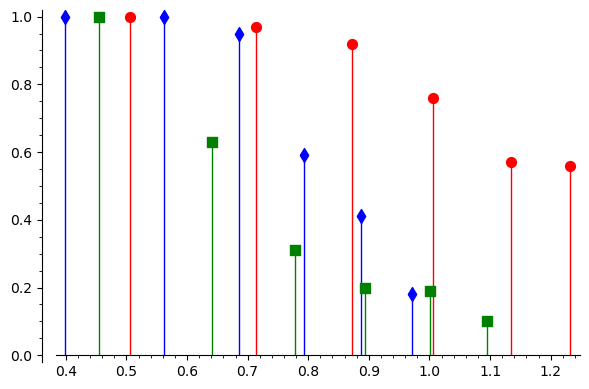

In [110]:
#
# success rate depending on (normalised) occlusion added
#
# Teapot = circle / red
# Bunny = square / green
# Cow = lozenge / blue
#
img = []
for entry in zip(data, [('o', 'red'), ('s', 'green'), ('d', 'blue')]):
    pic, mark = entry
    print(pic[0])
    stats = pic[1]
    img += [scatter_plot([(s[2],s[1]) for s in stats], marker=mark[0], markersize=50, facecolor=mark[1], edgecolor=None, xmin=0.4, ymin=0)]
    img += [polygon([(s[2],0.0), (s[2],s[1])], color=mark[1], thickness=1, xmin=0.4, ymin=0) for s in stats]
img = sum(img)
img.set_aspect_ratio('automatic')
img.plot().show()

Teapot.csv
Bunny.csv
Cow.csv


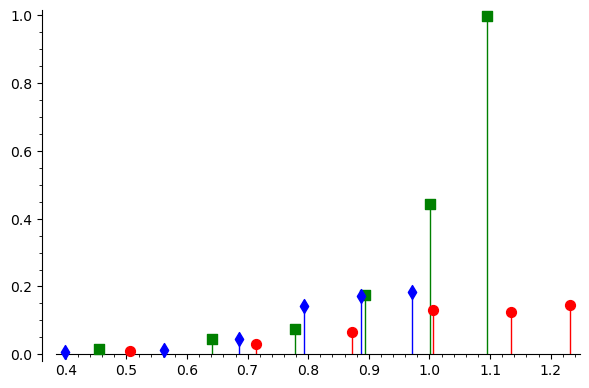

In [109]:
#
# distance to specimen depending on (normalised) occlusion added
#
# Teapot = circle / red
# Bunny = square / green
# Cow = lozenge / blue
#
img = []
for entry in zip(data, [('o', 'red'), ('s', 'green'), ('d', 'blue')]):
    pic, mark = entry
    print(pic[0])
    stats = pic[1]
    img += [scatter_plot([(s[2],s[6]) for s in stats], marker=mark[0], markersize=50, facecolor=mark[1], edgecolor=None, xmin=0.4, ymin=0)]
    img += [polygon([(s[2],0.0), (s[2],s[6])], color=mark[1], thickness=1, xmin=0.4, ymin=0) for s in stats]
img = sum(img)
img.set_aspect_ratio('automatic')
img.plot().show()

Teapot.csv
Bunny.csv
Cow.csv


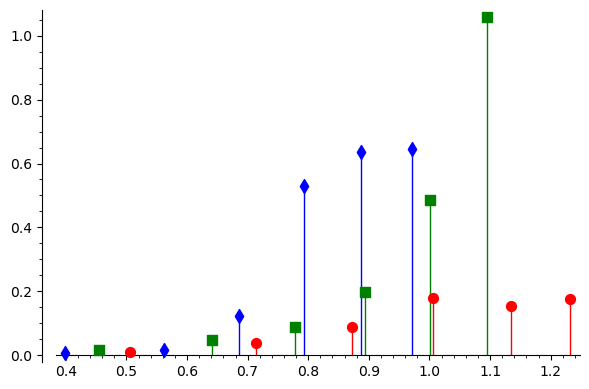

In [108]:
#
# distance to initial orthogonal transformation depending on (normalised) occlusion added
#
# Teapot = circle / red
# Bunny = square / green
# Cow = lozenge / blue
#
img = []
for entry in zip(data, [('o', 'red'), ('s', 'green'), ('d', 'blue')]):
    pic, mark = entry
    print(pic[0])
    stats = pic[1]
    img += [scatter_plot([(s[2],s[7]) for s in stats], marker=mark[0], markersize=50, facecolor=mark[1], edgecolor=None, xmin=0.4, ymin=0)]
    img += [polygon([(s[2],0.0), (s[2],s[7])], color=mark[1], thickness=1, xmin=0.4, ymin=0) for s in stats]
img = sum(img)
img.set_aspect_ratio('automatic')
img.plot().show()